# Predicting whether or not an employee leaves a company after training

## Table of contents
#### Business Understanding
#### Data Understanding
#### Data Preparation
#### Modelling
#### Evaluation
#### Deployment

## Business understanding

A company, active in Big Data and Data Science, offers training to Data Scientists. The company then wishes to hire trainees who pass courses in the training. Moreover, other than demographics, education, experience data, the company collects information on Data Scientists who wish to leave or retain their current roles.

With the data, the company can allocate enough training resources to candidates who really want to work for them. This will reduce the cost and time the program will take. Also, the company can prioritize quality and better categorizing of candidates for better planning of the courses.

## Data Understanding

Binary problem with 0 representing and 1 representing in the target variable.

`enrollee_id`   
`city`  
`city_development_index`   
`gender`  
`relevent_experience`   
`enrolled_university`  
`education_level`  
`major_discipline`  
`experience`  
`company_size`  
`company_type`  
`last_new_job`  
`training_hours`  
`target`

In [6]:
# importing libraries and frameworks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

In [7]:
# Loading datasets into pandas dataframes
#test_data = pd.read_csv(r"C:\Users\Administrator\Documents\Predicting\aug_test.csv")
train_data = pd.read_csv("aug_train.csv")

# Creating a new dataframe, to retain a copy as train_data
data = train_data

In [8]:
# The first five rows of the dataset
data.head(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [9]:
# Dimensions of the array of the dataframe, i.e (rows, columns)
data.shape

(19158, 14)

In [26]:
# Checking descriptive statistcs of numeric columns
data.describe(include=[np.number])

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [22]:
# Descriptive statistics of string columns
data.describe(include=[np.object])

,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job
count,19158,14650,19158,18772,18698,16345,19093,13220,13018,18735
unique,123,3,2,3,5,6,22,8,6,6
top,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1
freq,4355,13221,13792,13817,11598,14492,3286,3083,9817,8040


In [9]:
# A look at number of none null values, and datatype of each column of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

As presented above, the data has missing values in some of its columns. The data types of each column are clearly shown.

### Data Preparation

Duplicate values, missing values, and outliers.

### Duplicates
These are rows that have the same entries across all columns.

In [13]:
# Checking for duplicated entries, in all columns, ordering
#data.duplicated(subset=None, keep='last')

# Sum of duplicates
data.duplicated().sum()

0

In [14]:
# dropping duplicates
data.drop_duplicates(inplace=True)

There are no duplicates in the dataframe

### Missing Values

In [17]:
data.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [18]:
# Percentage of missing values in each column of the data frame.
(data.isnull().sum()/len(data.axes[0])*100).sort_values(ascending=False)

company_type              32.049274
company_size              30.994885
gender                    23.530640
major_discipline          14.683161
education_level            2.401086
last_new_job               2.207955
enrolled_university        2.014824
experience                 0.339284
enrollee_id                0.000000
city                       0.000000
city_development_index     0.000000
relevent_experience        0.000000
training_hours             0.000000
target                     0.000000
dtype: float64

The `company_type` column has the highest number of null values at about 32%.

#### Experience

Checking whether a candidate with relevant experience has missing data in the experience column.

In [22]:
data.query("experience != experience and relevent_experience == 'Has relevent experience'")

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
391,12038,city_90,0.698,Male,Has relevent experience,Full time course,Masters,NaN,NaN,NaN,NaN,NaN,44,1.0
2727,14965,city_103,0.920,NaN,Has relevent experience,no_enrollment,Masters,STEM,NaN,NaN,NaN,NaN,70,0.0
3086,19706,city_11,0.550,NaN,Has relevent experience,Full time course,Primary School,NaN,NaN,<10,Early Stage Startup,NaN,62,1.0
3564,15273,city_103,0.920,NaN,Has relevent experience,no_enrollment,Masters,STEM,NaN,NaN,NaN,NaN,34,0.0
3760,21042,city_103,0.920,NaN,Has relevent experience,Full time course,Graduate,STEM,NaN,50-99,Funded Startup,>4,24,0.0
4207,9306,city_67,0.855,Male,Has relevent experience,no_enrollment,Masters,Business Degree,NaN,NaN,Pvt Ltd,>4,96,1.0
5043,18350,city_21,0.624,NaN,Has relevent experience,Full time course,Graduate,STEM,NaN,50-99,Pvt Ltd,1,20,1.0
5670,7907,city_21,0.624,NaN,Has relevent experience,no_enrollment,Graduate,STEM,NaN,NaN,Funded Startup,NaN,27,0.0
6334,8082,city_16,0.910,NaN,Has relevent experience,no_enrollment,Masters,Other,NaN,50-99,Pvt Ltd,2,40,0.0
6554,17799,city_103,0.920,NaN,Has relevent experience,no_enrollment,Masters,STEM,NaN,10000+,NaN,NaN,64,0.0


Dropping null values since they are 0.33% of the total.

In [24]:
data = data.dropna(subset=['experience'])

#### Enrolled_university
Let's have a look at the unique values in the column.

In [26]:
data.query("enrolled_university == 'no_enrollment' & education_level == 'Masters'")

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
20,31972,city_159,0.843,Male,Has relevent experience,no_enrollment,Masters,STEM,11,100-500,Pvt Ltd,1,68,0.0
21,19061,city_114,0.926,Male,Has relevent experience,no_enrollment,Masters,STEM,11,100-500,Pvt Ltd,2,50,0.0
22,6491,city_102,0.804,NaN,Has relevent experience,no_enrollment,Masters,STEM,10,NaN,NaN,1,48,0.0
42,31654,city_21,0.624,NaN,Has relevent experience,no_enrollment,Masters,STEM,6,50-99,Early Stage Startup,1,112,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19131,18072,city_116,0.743,Male,No relevent experience,no_enrollment,Masters,STEM,8,10000+,NaN,1,48,0.0
19136,23672,city_21,0.624,NaN,Has relevent experience,no_enrollment,Masters,STEM,6,NaN,NaN,1,5,1.0
19138,19765,city_30,0.698,NaN,Has relevent experience,no_enrollment,Masters,STEM,11,100-500,Pvt Ltd,1,17,0.0
19148,9212,city_21,0.624,NaN,Has relevent experience,no_enrollment,Masters,STEM,3,100-500,Pvt Ltd,3,40,1.0


In [27]:
data['enrolled_university'].value_counts(dropna=False)

enrolled_university
no_enrollment       13778
Full time course     3737
Part time course     1197
NaN                   381
Name: count, dtype: int64

The column contains categorical data with the most common value being 'no_enrollment'. We can fill the 381 null values with the most common value.

In [29]:
data['enrolled_university'] = data['enrolled_university'].fillna(data['enrolled_university'].mode()[0])

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13580\4001391519.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['enrolled_university'] = data['enrolled_university'].fillna(data['enrolled_university'].mode()[0])


#### Education level

In [31]:
data['education_level'].value_counts(dropna=False)

education_level
Graduate          11566
Masters            4346
High School        2013
NaN                 450
Phd                 411
Primary School      307
Name: count, dtype: int64

Most candidates are graduates and thus, this is the most frequent value in this column. First, where a candidate's education level is missing but they have enrolled for university, part time or full time, we can impute 'High School' in their education level.

In [33]:
# Confirming that there are candidates with Nan in education_level but enrolled in university
data.query("education_level != education_level and enrolled_university != 'no_enrollment'")

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
301,30472,city_21,0.624,Male,No relevent experience,Full time course,NaN,NaN,4,1000-4999,Pvt Ltd,1,9,1.0
774,15297,city_103,0.920,NaN,No relevent experience,Full time course,NaN,NaN,<1,NaN,NaN,never,34,0.0
936,16948,city_21,0.624,NaN,No relevent experience,Full time course,NaN,NaN,2,NaN,NaN,never,61,0.0
941,10293,city_103,0.920,Male,No relevent experience,Part time course,NaN,NaN,9,NaN,NaN,2,77,1.0
1066,18667,city_21,0.624,NaN,Has relevent experience,Full time course,NaN,NaN,2,100-500,Pvt Ltd,1,12,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17106,18315,city_21,0.624,Male,No relevent experience,Part time course,NaN,NaN,2,50-99,Pvt Ltd,1,304,0.0
17146,23134,city_67,0.855,Male,No relevent experience,Full time course,NaN,NaN,2,NaN,NaN,never,87,0.0
18057,28895,city_150,0.698,NaN,Has relevent experience,Part time course,NaN,NaN,>20,10/49,Pvt Ltd,1,236,0.0
18113,20752,city_136,0.897,Male,No relevent experience,Part time course,NaN,NaN,2,10000+,Pvt Ltd,1,26,0.0


In [34]:
# Imputing 'High school' as a candidate's education level, if they have enrolled for university.
data.loc[data['education_level'].isnull() & (data['enrolled_university'] != 'no_enrollment'), 'education_level'] = 'Hign School'

The rest of the null values in the education level column,are dropped.

In [36]:
data = data.dropna(subset=['education_level'])

#### Last New Job
Difference in years between previous job and current job.

In [38]:
data['last_new_job'].value_counts(dropna=False)

last_new_job
1        7930
>4       3239
2        2870
never    2292
4        1020
3        1008
NaN       371
Name: count, dtype: int64

In [39]:
data['last_new_job'] = data['last_new_job'].fillna('never')

#### Major discipline

In [41]:
data['major_discipline'].value_counts(dropna=False)

major_discipline
STEM               14451
NaN                 2433
Humanities           668
Other                377
Business Degree      326
Arts                 252
No Major             223
Name: count, dtype: int64

Since there's no other information on a candidate's major discipline, All null values are imputed with 'Other'.

In [43]:
data['major_discipline'] = data['major_discipline'].fillna('Other')

#### Gender

In [45]:
data['gender'].value_counts(dropna=False)

gender
Male      13007
NaN        4309
Female     1232
Other       182
Name: count, dtype: int64

To maintain the consistency of the data, the most frequent value is imputed to the missing values

In [47]:
data['gender'] = data['gender'].fillna(data['gender'].mode()[0])

#### Company Size
Number of employees in a company.

In [49]:
data['company_size'].value_counts(dropna=False)

company_size
NaN          5658
50-99        3047
100-500      2542
10000+       2006
10/49        1451
1000-4999    1313
<10          1293
500-999       866
5000-9999     554
Name: count, dtype: int64

In [50]:
data['company_size'] = data['company_size'].fillna(data['company_size'].mode()[0])

Renaming values for consistency

In [52]:
data['company_size'] = data['company_size'].replace('10/49', '10-49')
data['company_size'] = data['company_size'].replace('<10', '0-10')
data['company_size'] = data['company_size'].replace('100-500', '100-499')
data['company_size'] = data['company_size'].replace('10000+', '>10000')

#### Company Type

In [54]:
data['company_type'].value_counts(dropna=False)

company_type
Pvt Ltd                9707
NaN                    5853
Funded Startup          994
Public Sector           944
Early Stage Startup     596
NGO                     517
Other                   119
Name: count, dtype: int64

In [55]:
data['company_type'] = data['company_type'].fillna('Unknown')

In [56]:
data['company_type'].value_counts(dropna=False)

company_type
Pvt Ltd                9707
Unknown                5853
Funded Startup          994
Public Sector           944
Early Stage Startup     596
NGO                     517
Other                   119
Name: count, dtype: int64

In [87]:
data.isnull().sum()

enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

In [89]:
data.shape

(18730, 14)

### Exploratory Data Analysis

Looking at how the data is distributed to understand it better.

#### Univariate Data Analysis

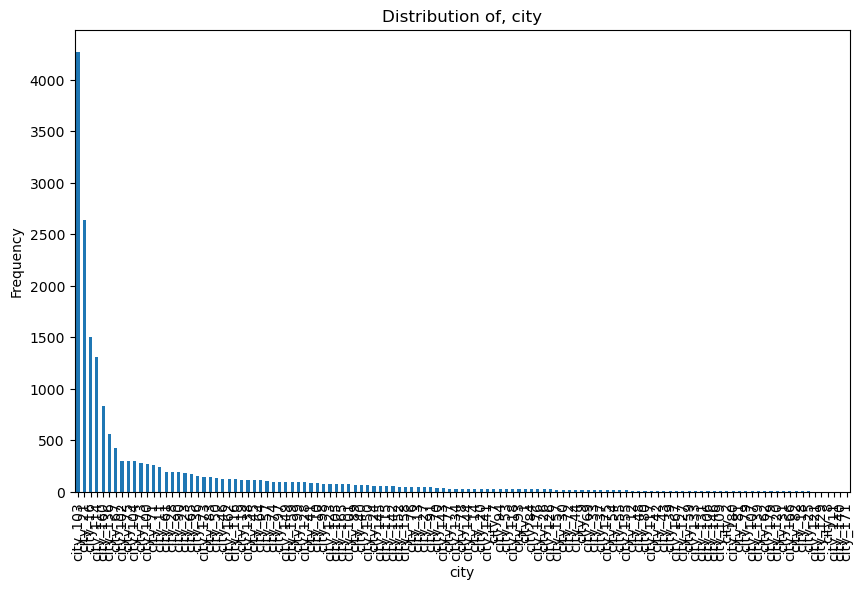

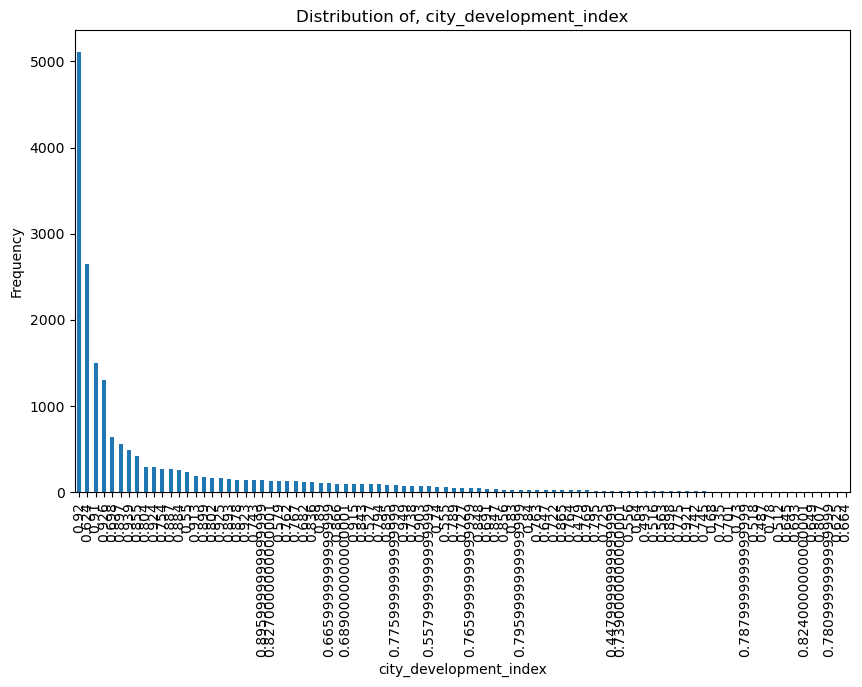

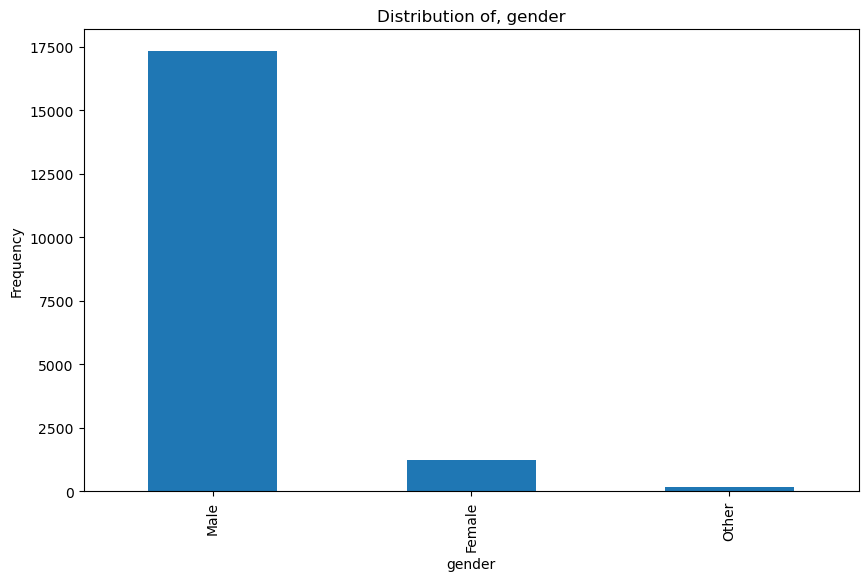

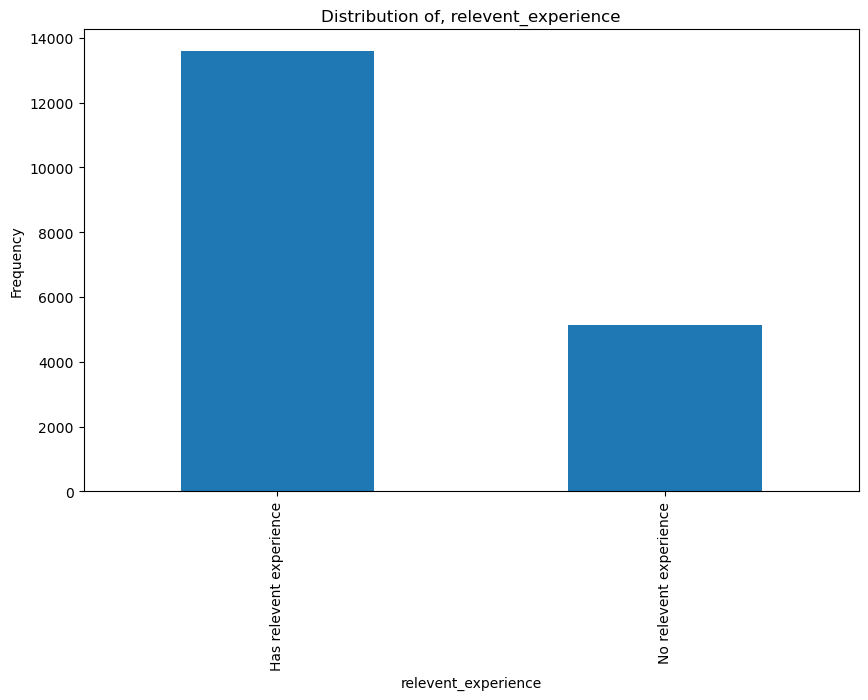

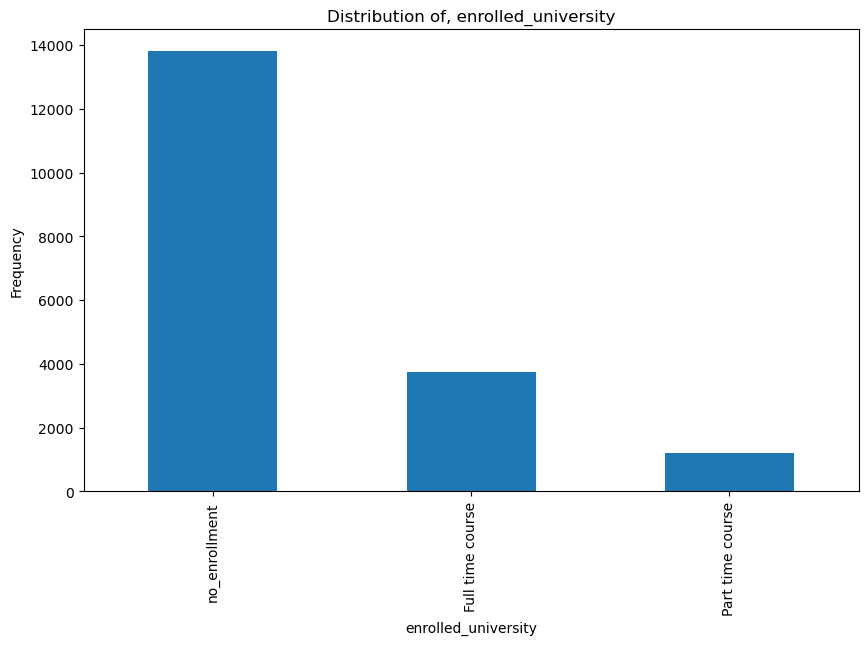

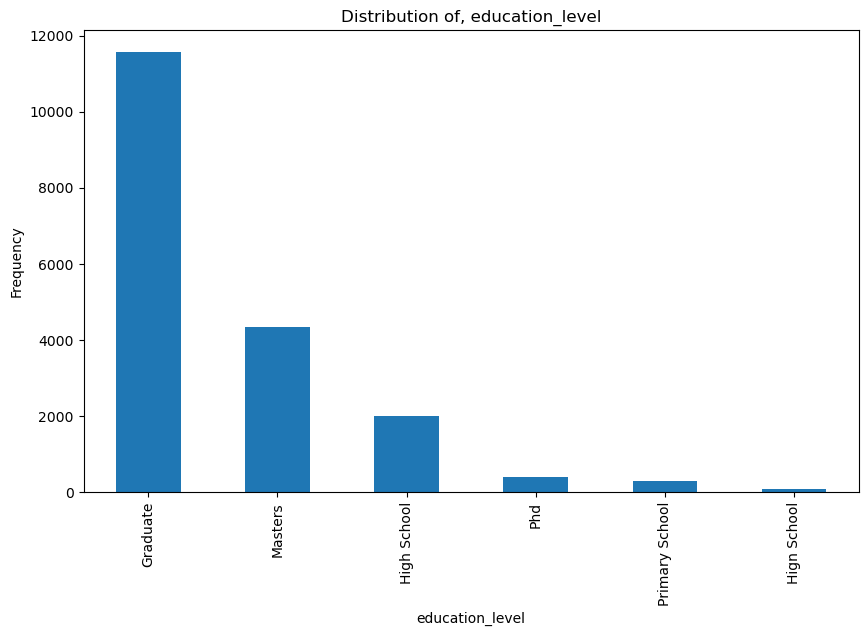

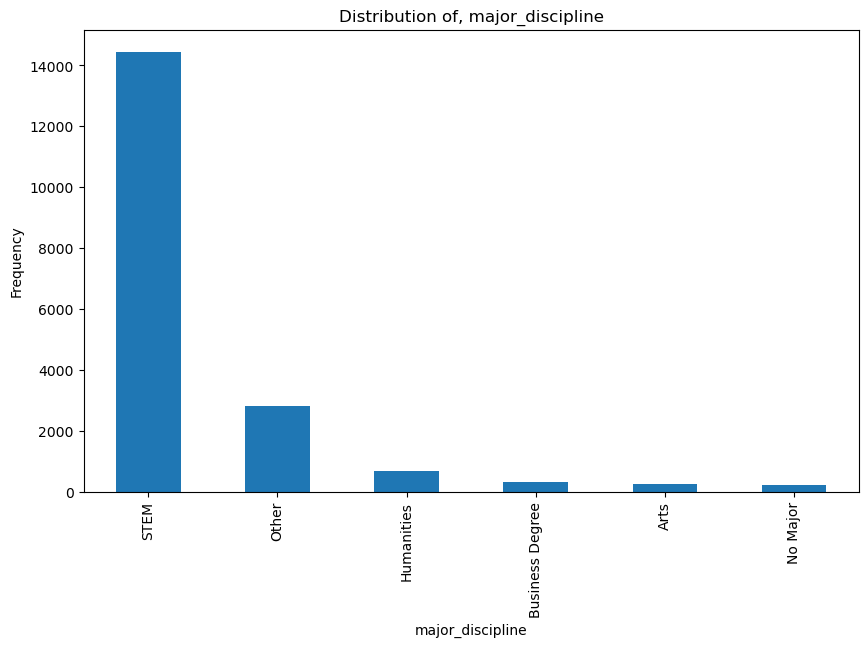

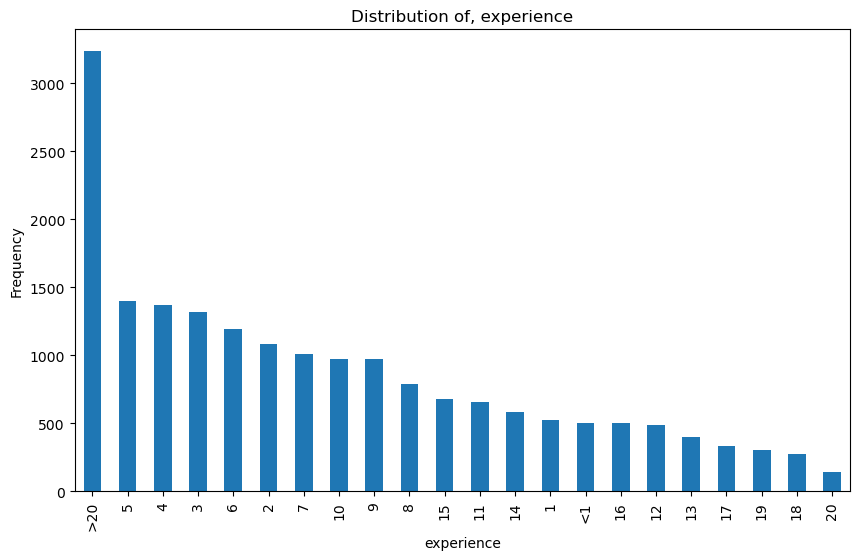

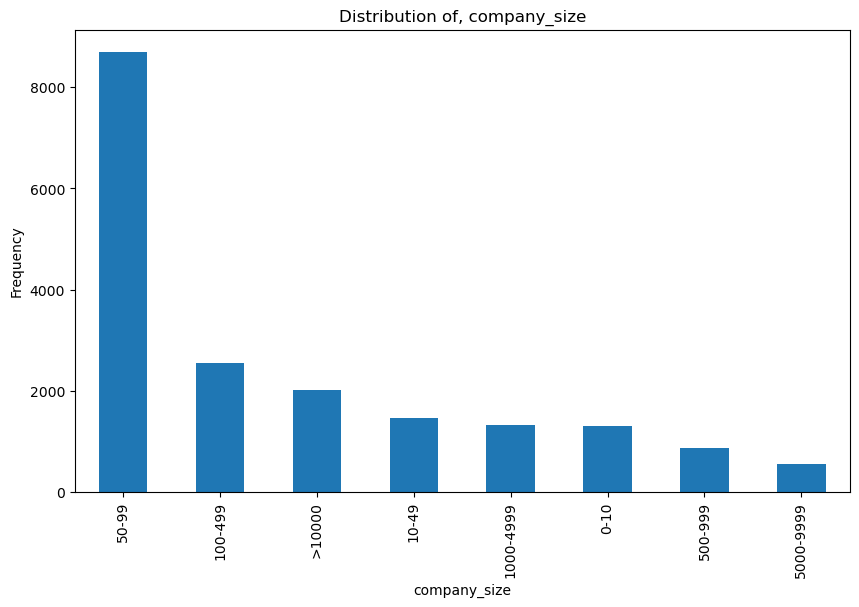

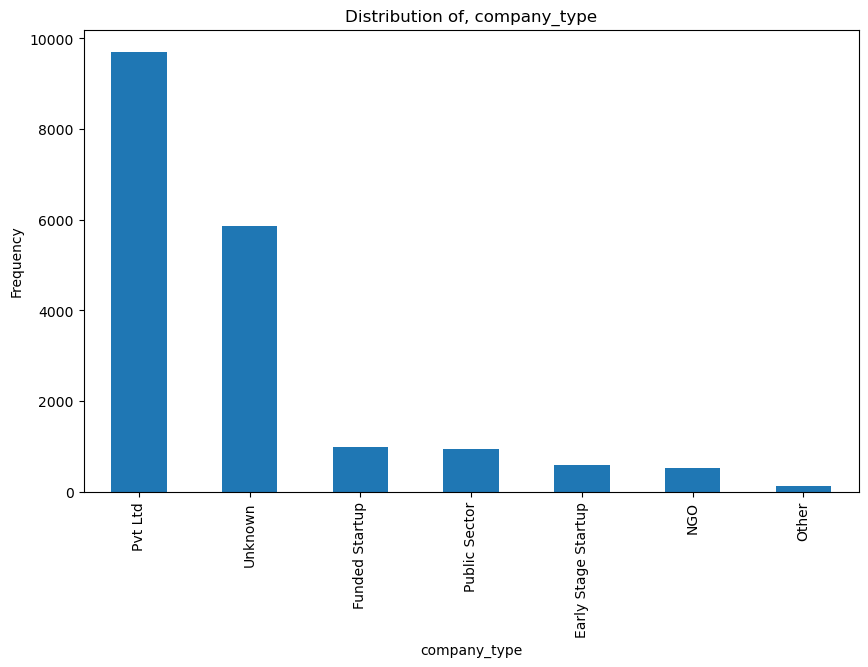

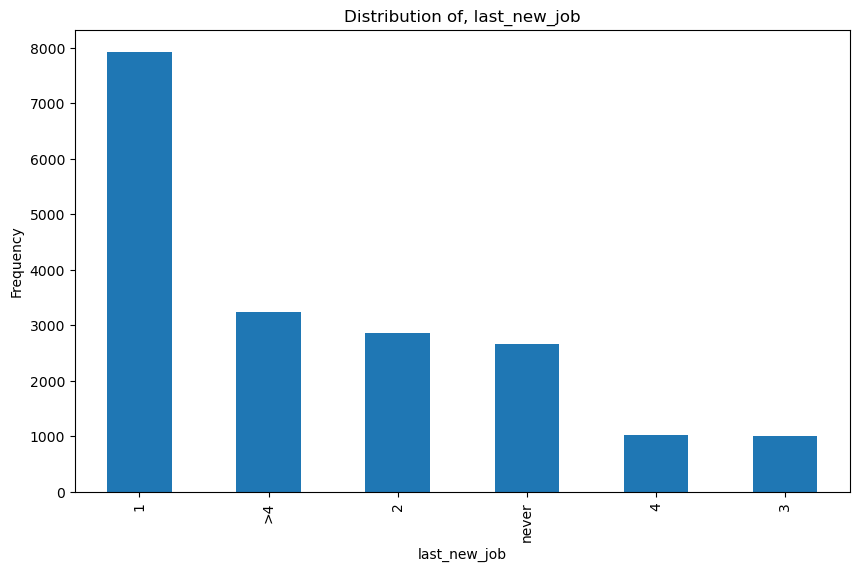

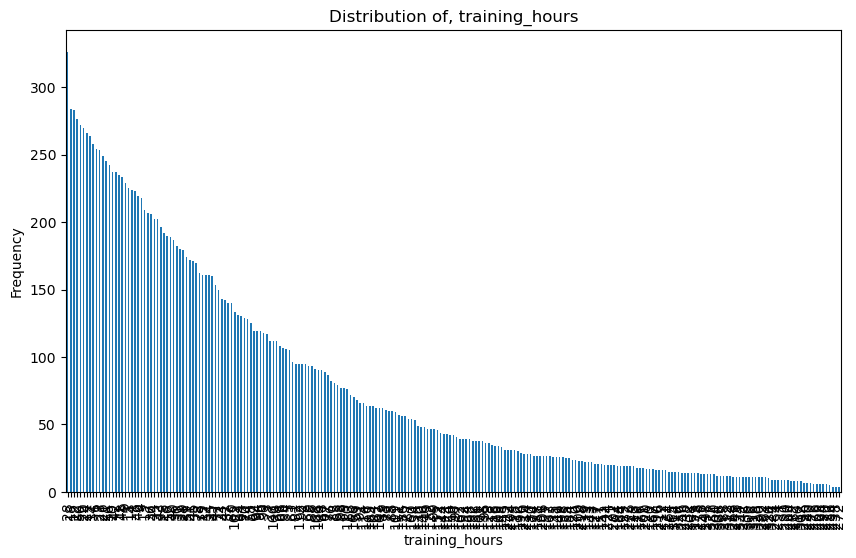

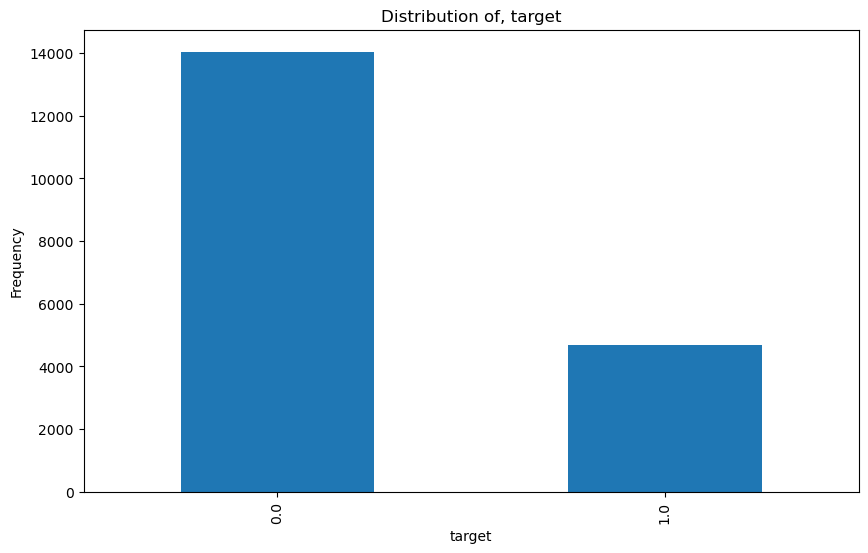

In [96]:
for col in data.columns:
    # Columns not to be plotted
    if col != 'enrollee_id':
        # Creating a variable that contains unique values in  a column for plotting
        my_plot = data[col].value_counts()
        
        # selecting the figure size
        plt.figure(figsize=(10,6))
        my_plot.plot(kind='bar')
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show


#### Multivariate Data Analysis

## Data Preparation

In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18730 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             18730 non-null  int64  
 1   city                    18730 non-null  object 
 2   city_development_index  18730 non-null  float64
 3   gender                  18730 non-null  object 
 4   relevent_experience     18730 non-null  object 
 5   enrolled_university     18730 non-null  object 
 6   education_level         18730 non-null  object 
 7   major_discipline        18730 non-null  object 
 8   experience              18730 non-null  object 
 9   company_size            18730 non-null  object 
 10  company_type            18730 non-null  object 
 11  last_new_job            18730 non-null  object 
 12  training_hours          18730 non-null  int64  
 13  target                  18730 non-null  float64
dtypes: float64(2), int64(2), object(10)
memory 

In [99]:
data.dtypes

enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object

### Encoding Data
Encoding all categorical columns

In [ ]:
# One hot encoding
'city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'target'

In [ ]:
'training_hours',

## Modelling